<a href="https://colab.research.google.com/github/Kuoz2/An-lisis_y_Predicci-n/blob/main/Clasificaci%C3%B3n_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv('/content/drive/MyDrive/CURSOPYTHON/heart_disease_uci.csv')

print("--- Información General de la Estructura ---")
display(df.info())

print("\n--- Estadísticas Descriptivas ---")
display(df.describe())

print("\n--- Conteo de Valores Faltantes ---")
print(df.isnull().sum())

--- Información General de la Estructura ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


None


--- Estadísticas Descriptivas ---


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000



--- Conteo de Valores Faltantes ---
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


### **1. Carga de Datos e Inspección Inicial**

En esta sección, cargamos el conjunto de datos `heart_disease_uci.csv` en un DataFrame de Pandas y realizamos una inspección inicial para entender su estructura, tipos de datos y la presencia de valores nulos.

*   **`df.info()`**: Muestra un resumen conciso del DataFrame, incluyendo el número de entradas, el número total de columnas, el tipo de datos de cada columna y la cantidad de valores no nulos.
*   **`df.describe()`**: Genera estadísticas descriptivas para las columnas numéricas, como la media, la desviación estándar, los valores mínimos y máximos, y los cuartiles.
*   **`df.isnull().sum()`**: Calcula y muestra el número total de valores nulos por cada columna, lo cual es crucial para la fase de limpieza de datos.

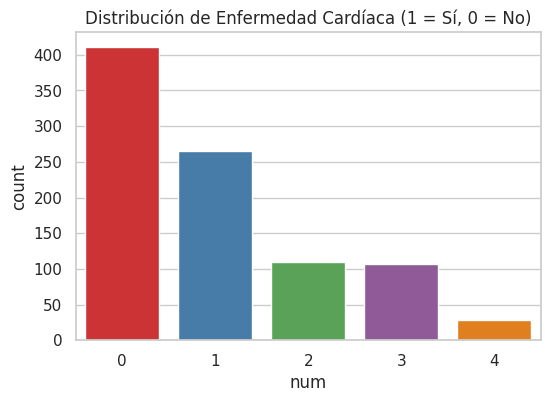

In [9]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(x='num', data=df, palette='Set1')
plt.title('Distribución de Enfermedad Cardíaca (1 = Sí, 0 = No)')
plt.show()

### **2. Análisis Exploratorio de Datos (EDA)**

En esta sección, visualizamos la distribución de las variables clave y las relaciones entre ellas para obtener una mejor comprensión de los datos.

*   **Distribución de la Variable Objetivo (`num`)**: Un gráfico de conteo muestra la distribución de las diferentes categorías de la enfermedad cardíaca en el dataset. Es crucial entender si la variable objetivo está balanceada o desbalanceada, lo que podría influir en la elección del modelo y las métricas de evaluación.
*   **Distribución de Edades y Frecuencia Cardíaca Máxima (`age`, `thalch`)**: Histogramas con curvas de densidad (KDE) nos permiten observar la distribución de estas variables numéricas. Esto ayuda a identificar si siguen una distribución normal, si hay asimetrías o la presencia de múltiples picos.
*   **Relación entre Edad, Colesterol y Enfermedad (`age`, `chol`, `num`)**: Un diagrama de dispersión visualiza la relación entre `age` y `chol`, con puntos coloreados según la categoría de `num`. Esto puede revelar patrones o agrupaciones en los datos que sugieran correlaciones con la enfermedad cardíaca.
*   **Mapa de Calor de Correlaciones**: Un mapa de calor muestra las correlaciones de Pearson entre todas las variables numéricas. Los colores y los valores numéricos indican la fuerza y dirección de la relación lineal entre pares de variables, ayudando a identificar características altamente correlacionadas.

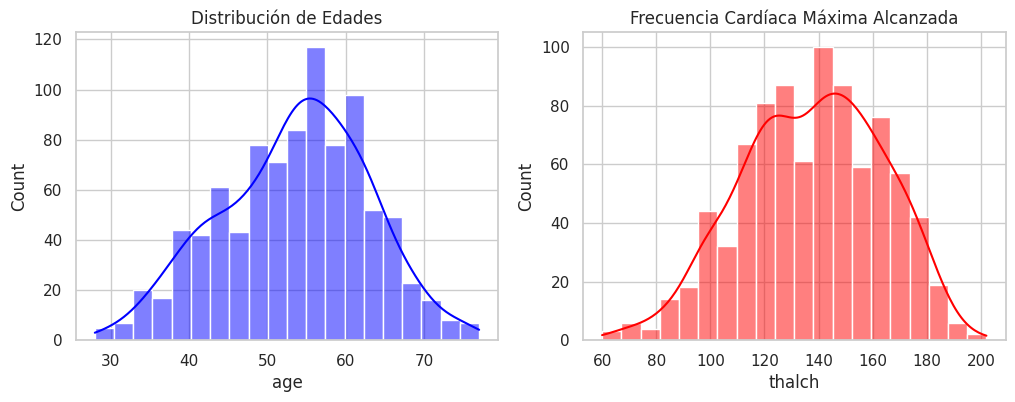

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['age'], bins=20, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribución de Edades')
sns.histplot(df['thalch'], bins=20, kde=True, ax=axes[1], color='red')
axes[1].set_title('Frecuencia Cardíaca Máxima Alcanzada')
plt.show()

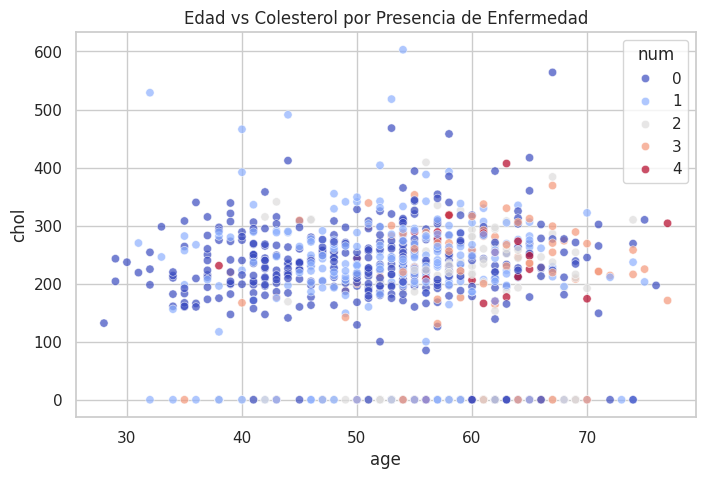

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='chol', hue='num', data=df, alpha=0.7, palette='coolwarm')
plt.title('Edad vs Colesterol por Presencia de Enfermedad')
plt.show()

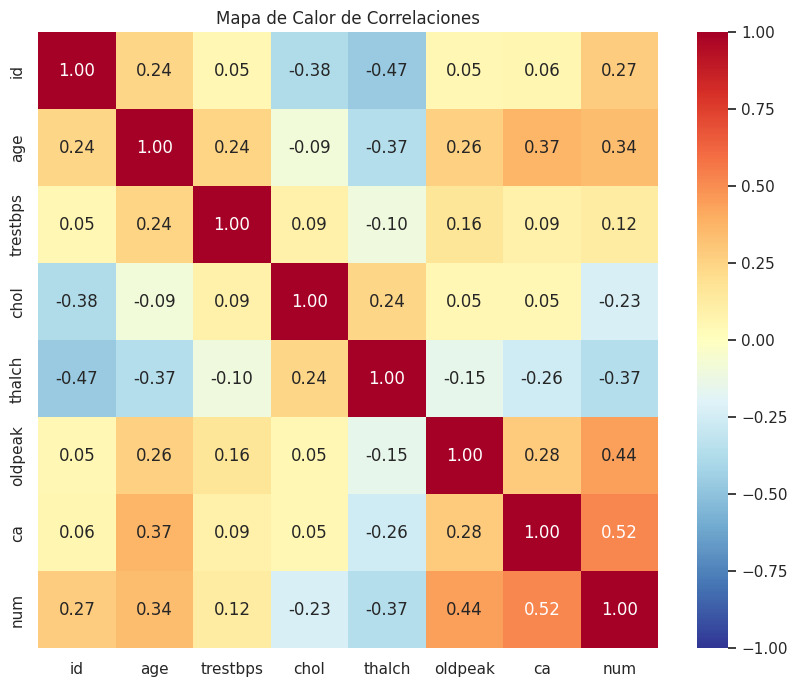

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlBu_r', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

### **3. Limpieza de Datos - Tratamiento de Outliers**

Identificamos y tratamos los valores atípicos (outliers) en las columnas `chol` (colesterol) y `trestbps` (presión arterial en reposo) utilizando el método de capping basado en el rango intercuartílico (IQR).

*   Para cada columna, calculamos el primer cuartil (Q1) y el tercer cuartil (Q3).
*   El Rango Intercuartílico (IQR) se calcula como la diferencia entre Q3 y Q1.
*   Definimos un límite superior para los outliers como `Q3 + 1.5 * IQR`.
*   Cualquier valor en la columna que exceda este límite superior es reemplazado por el valor del límite superior (capping). Esto ayuda a reducir la influencia de valores extremos sin eliminarlos por completo del conjunto de datos.

In [17]:
for col in ['chol', 'trestbps']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > limite_superior, limite_superior, df[col])

print("\nOutliers tratados mediante capping (IQR).")


Outliers tratados mediante capping (IQR).


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [20]:
X = df.drop('num', axis=1)
y = df['num']

In [26]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

In [24]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

# 5. Aplicar transformaciones de forma segura
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("Preprocesamiento finalizado. Dimensiones de entrenamiento:", X_train_proc.shape)

Preprocesamiento finalizado. Dimensiones de entrenamiento: (736, 20)


Columns in X: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Columns in num_cols: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']


In [31]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

In [33]:
def calcular_metricas(y_real, y_pred, y_prob):
    return {
        'Exactitud (Accuracy)': accuracy_score(y_real, y_pred),
        'Precisión': precision_score(y_real, y_pred, average='weighted'),
        'Recall (Sensibilidad)': recall_score(y_real, y_pred, average='weighted'),
        'F1-Score': f1_score(y_real, y_pred, average='weighted'),
        'ROC-AUC': roc_auc_score(y_real, y_prob, multi_class='ovr') # For multiclass, 'ovr' (one-vs-rest) or 'ovo' (one-vs-one) is needed
    }
xgb_base = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss') # Changed eval_metric for multiclass
xgb_base.fit(X_train_proc, y_train)

y_pred_base = xgb_base.predict(X_test_proc)
y_prob_base = xgb_base.predict_proba(X_test_proc)
metricas_base = calcular_metricas(y_test, y_pred_base, y_prob_base)

In [34]:
print("Iniciando búsqueda exhaustiva de hiperparámetros (GridSearchCV)...")
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_proc, y_train)
xgb_optimizado = grid_search.best_estimator_

print(f"\n¡Optimización completada! Mejores parámetros encontrados:")
print(grid_search.best_params_)

Iniciando búsqueda exhaustiva de hiperparámetros (GridSearchCV)...

¡Optimización completada! Mejores parámetros encontrados:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 150, 'subsample': 0.8}


In [36]:
y_pred_opt = xgb_optimizado.predict(X_test_proc)
y_prob_opt = xgb_optimizado.predict_proba(X_test_proc)
metricas_opt = calcular_metricas(y_test, y_pred_opt, y_prob_opt)

# --- 4. Comparativa de Resultados ---
df_comparativa = pd.DataFrame([metricas_base, metricas_opt],
                              index=['XGBoost Base', 'XGBoost Optimizado'])

print("\n--- Comparativa Final de Rendimiento en Conjunto de Prueba ---")
display(df_comparativa)


--- Comparativa Final de Rendimiento en Conjunto de Prueba ---


,Exactitud (Accuracy),Precisión,Recall (Sensibilidad),F1-Score,ROC-AUC
XGBoost Base,0.581522,0.558952,0.581522,0.568623,0.789357
XGBoost Optimizado,0.597826,0.568798,0.597826,0.579525,0.796645


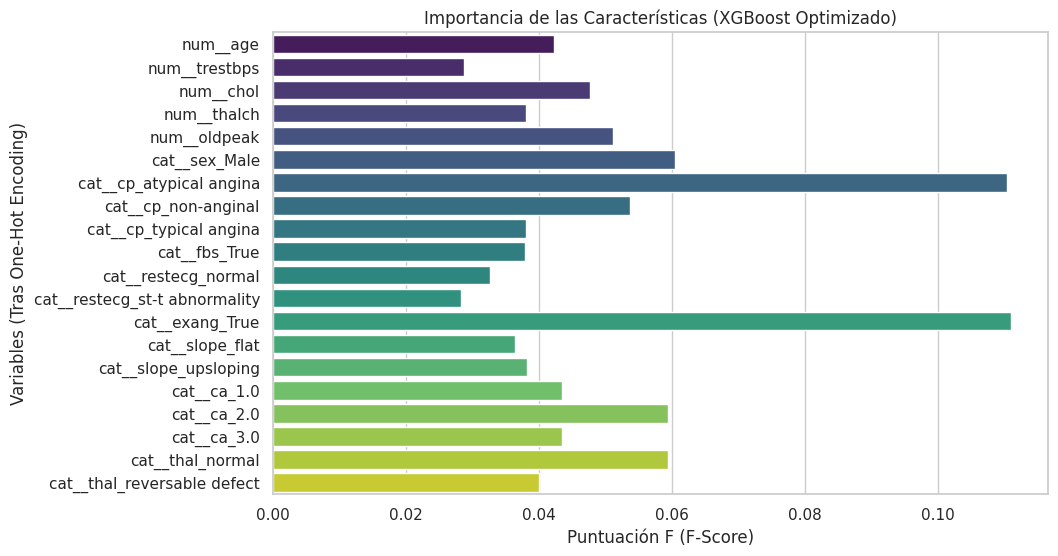

In [37]:
nombres_caracteristicas = preprocessor.get_feature_names_out()
importancia = xgb_optimizado.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x=importancia, y=nombres_caracteristicas, palette='viridis')
plt.title('Importancia de las Características (XGBoost Optimizado)')
plt.xlabel('Puntuación F (F-Score)')
plt.ylabel('Variables (Tras One-Hot Encoding)')
plt.show()